# Purpose:

The purpose of this notebook is to utilise the gold-layer dataset to train and evaluate various machine learning models aimed at predicting high-risk customers.

## Import

In [1]:

import pandas as pd
from autogluon.tabular import TabularPredictor
from src.data_vis_utils import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


import warnings
warnings.filterwarnings("ignore", message="load_learner` uses Python's insecure pickle module*")



# Dataset

In [2]:
df = pd.read_csv("dataset/gold/gold_customer_features.csv")

In [3]:
df

,customer_account,total_invoices,total_amount,total_settled,total_balance,avg_days_to_pay,median_days_to_pay,late_payment_ratio,unpaid_ratio,aged_debt_count,...,experian_credit_score,segment_id,cust_group,sme_mbs,payment_method,sales_route,segment,count_sites,tenure_group,contracted_annual_volume
0,880000000010,9,5854.26,5854.26,0.00,14.444444,14.0,0.222222,0.0,0,...,84.0,FARMING_AGRICULTURE,SOLPAR,SME,DD,Direct,Fixed,1,90 days - 6 months,7397
1,880000000013,10,8847.96,8847.96,0.00,11.700000,14.0,0.200000,0.0,0,...,94.0,RETAIL,LTD,SME,DD,Indirect,Fixed,1,1-3 years,6488
2,880000000031,24,2677.62,2677.62,0.00,16.041667,14.0,0.291667,0.0,0,...,44.0,RETAIL,LTD,SME,DD,Direct,VBR,1,<90 days,4581
3,880000000049,24,5689.81,5689.81,0.00,14.541667,14.0,0.333333,0.0,0,...,85.0,HEALTH,LTD,SME,DD,Direct,Fixed,1,6 months - 1 year,8615
4,880000000054,3,15629.39,15629.39,0.00,21.000000,17.0,1.000000,0.0,0,...,83.0,FARMING_AGRICULTURE,SOLPAR,SME,NONDD,Direct,Fixed,1,90 days - 6 months,18373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,880000243901,2,2814.59,0.00,2814.59,NaN,NaN,0.000000,1.0,2,...,99.0,CONSTRUCTION,LTD,SME,NONDD,Direct,VBR,1,6 months - 1 year,30702
9995,880000243959,2,244.64,0.00,244.64,NaN,NaN,0.000000,1.0,2,...,99.0,UNCLASSIFIED,LTD,SME,NONDD,Direct,VBR,1,<90 days,2536
9996,880000244105,2,4284.54,0.00,4284.54,NaN,NaN,0.000000,1.0,2,...,99.0,MANAGEMENT_CONSULTAN,LTD,SME,NONDD,Direct,VBR,1,90 days - 6 months,43748
9997,880000244297,2,3575.92,0.00,3575.92,NaN,NaN,0.000000,1.0,2,...,99.0,PROFESSIONAL_SPECIAL,SOLPAR,SME,NONDD,Direct,VBR,1,6 months - 1 year,18336


## **Risk Threshold Analysis**

Before training the model, we first need to define what constitutes a risky customer. While there are several approaches to this, for the purpose of this proof of concept (PoC), we will use the unpaid ratio as the basis for classifying customers as risky or not risky.

To begin, we'll run a simple experiment to help identify a suitable risk threshold. By plotting customer count against unpaid ratio, we can visualise how many customers would be classified as risky at different threshold levels. This will inform our decision on selecting an appropriate unpaid ratio cutoff.

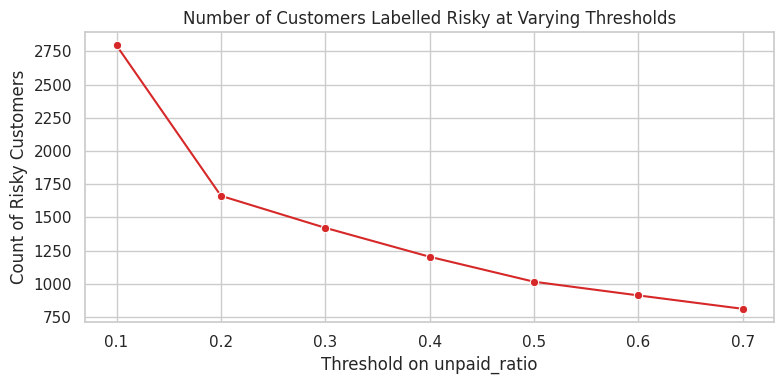

In [4]:

plot_risk_threshold_sensitivity(df)

The chart above shows the relationship between the unpaid ratio threshold and the number of customers labeled as risky. As expected, lower thresholds result in a larger number of customers being classified as risky.

While a more accurate threshold would ideally be defined in consultation with subject matter experts (SMEs), for the purpose of this PoC, we will adopt a working definition:

**Customers with an unpaid ratio of 0.3 (30% of invoice unpaided) or higher will be labeled as risky, while those below this threshold will be considered not risky.**

In [5]:
risk_threshold = 0.3 

## Dataset

We will now generate the labeled dataset using the defined risk threshold and proceed to split it into training and testing sets. For this PoC, we will use an 80/20 split, where 80% of the data will be used for training and 20% reserved for testing.

In [6]:
def create_train_test(test_size=0.2, risk_threshold=risk_threshold):
    df = pd.read_csv("dataset/gold/gold_customer_features.csv")

    # a binary target variable: 1 if unpaid_ratio > threshold (risky), else 0
    df['target_risky'] = df['unpaid_ratio'] > risk_threshold  

    # Stratified split to preserve target distribution
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=42,
        stratify=df['target_risky']  # Ensures class balance in both train and test sets
    )

    print(f"Train: {train_df.shape}, Test: {test_df.shape}")

    return train_df, test_df

Let's split our dataset into train and test

In [7]:
train_df, test_df = create_train_test()

Train: (7999, 23), Test: (2000, 23)


## ML models

We will now proceed with model training and validation. For this PoC, we have chosen to use AutoGluon (https://auto.gluon.ai/stable/index.html), an AutoML framework that streamlines the training of machine learning models on tabular datasets.

AutoGluon automatically evaluates a range of models, providing key outputs such as model performance metrics, feature importance, and the best-performing model. This approach significantly reduces the time and effort required for model development while maintaining strong baseline performance.

Let's write few utility function for training

In [8]:


def model_training(train_df,
                   test_df,
                   target_col_name,
                   drop_feature_list,
                   risk_score_filename="clean_risk_scores.csv", 
                   features_importance_filename="clean_feature_importance.csv", 
                   automl_train_mode='medium', 
                   model_store_path='models/AutoML/'):
    
    # Prepare training features
    X_train = train_df.drop(columns=drop_feature_list)
    y_train = train_df[target_col_name]
    
    train_data = X_train.copy()
    train_data[target_col_name] = y_train

    print(f"Training on features: {X_train.columns.tolist()}")

    # Train AutoGluon
    predictor = TabularPredictor(label=target_col_name, path=model_store_path).fit(
        train_data,
        presets=automl_train_mode
    )

    # # Predict on test data
    X_test = test_df.drop(columns=drop_feature_list)
    test_df = test_df.copy() 
    probas = predictor.predict_proba(X_test)

    # Add risk probabilities to test set
    test_df['risk_probability'] = probas[probas.columns[-1]]

    # Save test risk scores
    test_df[['customer_account', 'risk_probability']].to_csv(f"models/{risk_score_filename}", index=False)

    # Feature importance (based on training)
    fi = predictor.feature_importance(train_data)
    fi.to_csv(f"models/{features_importance_filename}", index=False)

    # Evaluate model on test set if target is known
    if target_col_name in test_df.columns:
        y_true = test_df[target_col_name]
        y_pred_proba = test_df['risk_probability']
        auc = roc_auc_score(y_true, y_pred_proba)
        print(f"\n --- Test AUC: {auc:.4f} -----")

    print("Model trained, risk scores and feature importance saved.")
    return predictor


def validation(testset, leak_cols, model, is_save_results=False):
    # Predict on test data
    X_test = testset.drop(columns=leak_cols)
    test_df = testset.copy() 
    probas = model.predict_proba(X_test)

    # Add risk probabilities to test set
    test_df['risk_probability'] = probas[probas.columns[-1]]

    risk_score_filename="clean_risk_scores.csv", 
   
    if is_save_results:
        # Save test risk scores
        test_df[['customer_account', 'risk_probability']].to_csv(f"models/{risk_score_filename}", index=False)


    plot_roc_curve(test_df['target_risky'], test_df['risk_probability'])
    plot_risk_distribution_by_class(test_df)
    plot_precision_recall(test_df['target_risky'], test_df['risk_probability'])

---

## Experment 1

In this experiment, we will train a model using all available features generated so far. The goal is to evaluate the model's initial performance and gain insights into its behaviour, including predictive power, feature importance, and overall effectiveness in identifying risky customers.

In [9]:
# Drop our traget col from train df
leak_cols_v1 = [
    'target_risky',
    'unpaid_ratio'
]

Let's train the model v1

In [10]:

train_df_v1 = train_df.copy()
test_df_v1 = test_df.copy()

model_v1= model_training(train_df_v1.copy(),
                   test_df_v1.copy(),
                   'target_risky',
                   leak_cols_v1,
                   risk_score_filename="clean_risk_scores_v1.csv", 
                   features_importance_filename="clean_feature_importance_v1.csv", 
                   automl_train_mode='medium', 
                   model_store_path='models/AutoML/v1')



Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.18
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Fri, 09 May 2025 10:53:27 +0000
CPU Count:          36
Memory Avail:       56.52 GB / 62.47 GB (90.5%)
Disk Space Avail:   92.98 GB / 482.97 GB (19.3%)
Presets specified: ['medium']
/home/anish/.local/share/mamba/envs/customer-risk-prediction/lib/python3.10/site-packages/autogluon/common/utils/utils.py:78: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Beginning AutoGluon training ...
AutoGluon will save models to "/home/anish/continues-learning/customer-risk-prediction/models/AutoML/v1

Training on features: ['customer_account', 'total_invoices', 'total_amount', 'total_settled', 'total_balance', 'avg_days_to_pay', 'median_days_to_pay', 'late_payment_ratio', 'aged_debt_count', 'aged_debt_amount', 'internal_credit_rating', 'experian_credit_score', 'segment_id', 'cust_group', 'sme_mbs', 'payment_method', 'sales_route', 'segment', 'count_sites', 'tenure_group', 'contracted_annual_volume']


	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 2 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original data (raw dtype, special dtypes):
		('float', [])  : 8 | ['total_amount', 'total_settled', 'total_balance', 'avg_days_to_pay', 'median_days_to_pay', ...]
		('int', [])    : 5 | ['customer_account', 'total_invoices', 'aged_debt_count', 'count_sites', 'contracted_annual_volume']
		('object', []) : 8 | ['internal_credit_rating', 'segment_id', 'cust_group', 'sme_mbs', 'payment_method', ...]
	Types of features in processed data (raw dtype, special dtypes):
		('category', [])  : 6 | ['internal_


 --- Test AUC: 0.9979 -----
Model trained, risk scores and feature importance saved.


In the results above, we can see that several tasks were automated by AutoGluon, including one-hot encoding of categorical variables, automatic train/validation splitting, and evaluation on the predefined test set.

The model achieved an exceptionally high AUC (Area Under the ROC Curve) of 0.9997, which is very close to 1. While this might initially appear impressive, such a high score is likely unrealistic and may indicate a data leakage issue - where target-related information has inadvertently been included in the training features.

We will address this in Experiment 2 by revisiting the feature set to reduce potential leakage.

---

For now, lets look at the models there were trained 

In [11]:
# Show model leaderboard
print("\nLeaderboard:")
leaderboard = model_v1.leaderboard(silent=True)
leaderboard



Leaderboard:


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.98375,accuracy,0.082552,13.973702,0.000652,0.079738,2,True,14
1,CatBoost,0.98000,accuracy,0.006027,3.700014,0.006027,3.700014,1,True,7
2,LightGBM,0.98000,accuracy,0.008824,0.782031,0.008824,0.782031,1,True,4
3,NeuralNetTorch,0.97875,accuracy,0.015880,27.780924,0.015880,27.780924,1,True,12
4,XGBoost,0.97750,accuracy,0.006656,0.666815,0.006656,0.666815,1,True,11
5,RandomForestEntr,0.97500,accuracy,0.165151,1.254725,0.165151,1.254725,1,True,6
6,RandomForestGini,0.97375,accuracy,0.166216,1.367884,0.166216,1.367884,1,True,5
7,LightGBMLarge,0.97250,accuracy,0.007660,1.371603,0.007660,1.371603,1,True,13
8,LightGBMXT,0.97125,accuracy,0.003558,0.804134,0.003558,0.804134,1,True,3
9,NeuralNetFastAI,0.97000,accuracy,0.021647,9.381194,0.021647,9.381194,1,True,10


In the above table, we can see that WeightEnsemble_L2 model receive the highest model accurracy followed by catboost and LightGBM. 

These features in provided data are not utilized by the predictor and will be ignored: ['unpaid_ratio']
Computing feature importance via permutation shuffling for 21 features using 5000 rows with 5 shuffle sets...
	24.34s	= Expected runtime (4.87s per shuffle set)
	13.33s	= Actual runtime (Completed 5 of 5 shuffle sets)
/home/anish/continues-learning/customer-risk-prediction/src/data_vis_utils.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='importance', y='index', palette=palette)
/home/anish/continues-learning/customer-risk-prediction/src/data_vis_utils.py:146: UserWarning: 
The palette list has fewer values (6) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='importance', y='index', palette=palette)


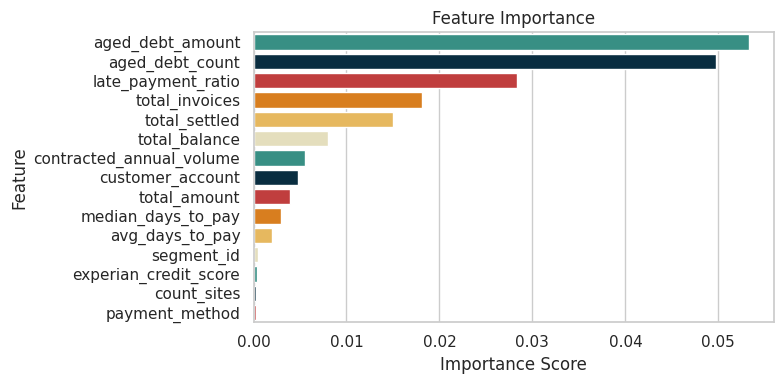

In [12]:

features_sorted_df = model_v1.feature_importance(train_df).reset_index().sort_values("importance", ascending=True)
plot_feature_importance(features_sorted_df, top_n=15)


The chart above displays the feature importance scores from the trained model. We observe that the top contributing features such as aged_debt_count, aged_debt_amount, and late_payment_ratio are highly correlated with each other.

Additionally, we see that customer_account, an identifier, was included as a feature, which may have introduced data leakage if it's implicitly tied to risk outcomes. Conversely, features like internal and external credit scores appear to have had minimal impact on the model’s decision-making.


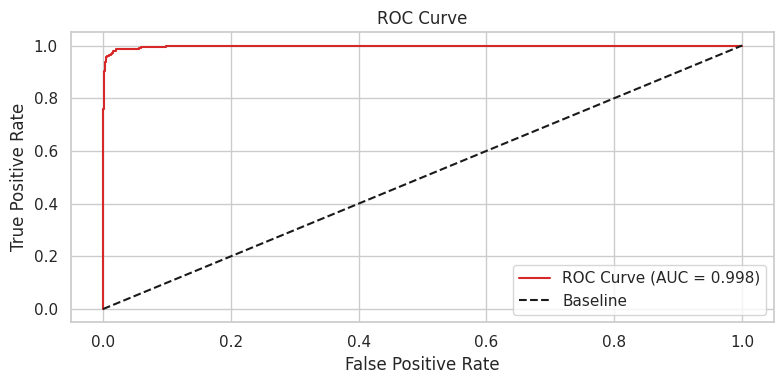

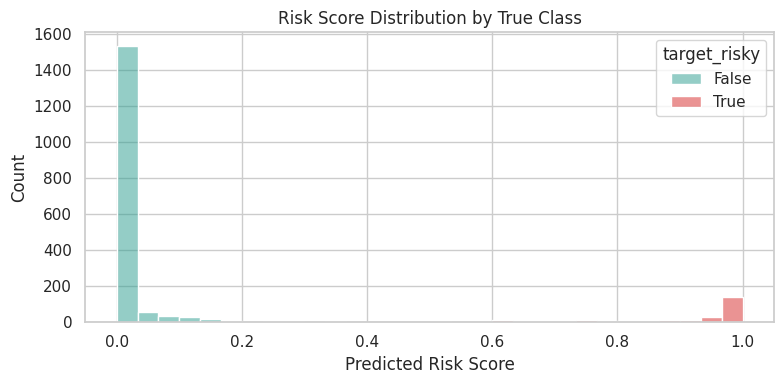

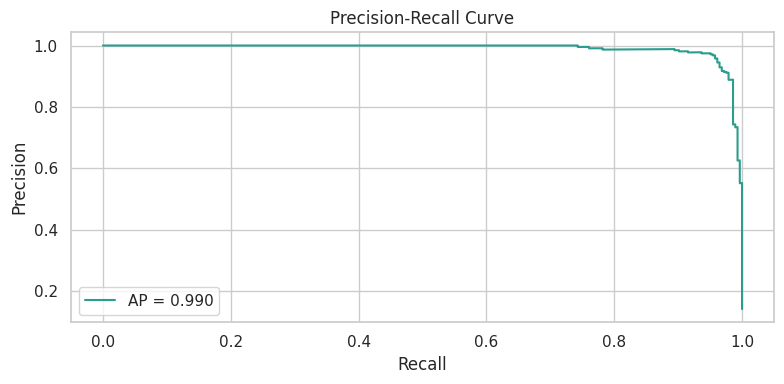

In [13]:
validation(test_df_v1, leak_cols_v1, model_v1, is_save_results=False)

---

# Experiment 2

Lets peform another experiment. Here will drop few of the features such be considered as might data leakage.

In [14]:
# Drop target + leakage features
leak_cols_v2 = [
'aged_debt_amount', 
'aged_debt_count' ,
'customer_account', 'target_risky',
'total_balance', 'unpaid_ratio'
]

train_df_v2 = train_df.copy()
test_df_v2 = test_df.copy()


In [15]:

model_v2= model_training(train_df_v2,
                   test_df_v2,
                   'target_risky',
                   leak_cols_v2,
                   risk_score_filename="clean_risk_scores_v2.csv", 
                   features_importance_filename="clean_feature_importance_v2.csv", 
                   automl_train_mode='medium', 
                   model_store_path='models/AutoML/v2')

Preset alias specified: 'medium' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.18
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Fri, 09 May 2025 10:53:27 +0000
CPU Count:          36
Memory Avail:       55.50 GB / 62.47 GB (88.8%)
Disk Space Avail:   92.98 GB / 482.97 GB (19.3%)
Presets specified: ['medium']
Beginning AutoGluon training ...
AutoGluon will save models to "/home/anish/continues-learning/customer-risk-prediction/models/AutoML/v2"
Train Data Rows:    7999
Train Data Columns: 17
Label Column:       target_risky
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [False, True]
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['bina

Training on features: ['total_invoices', 'total_amount', 'total_settled', 'avg_days_to_pay', 'median_days_to_pay', 'late_payment_ratio', 'internal_credit_rating', 'experian_credit_score', 'segment_id', 'cust_group', 'sme_mbs', 'payment_method', 'sales_route', 'segment', 'count_sites', 'tenure_group', 'contracted_annual_volume']


		('float', [])  : 6 | ['total_amount', 'total_settled', 'avg_days_to_pay', 'median_days_to_pay', 'late_payment_ratio', ...]
		('int', [])    : 3 | ['total_invoices', 'count_sites', 'contracted_annual_volume']
		('object', []) : 8 | ['internal_credit_rating', 'segment_id', 'cust_group', 'sme_mbs', 'payment_method', ...]
	Types of features in processed data (raw dtype, special dtypes):
		('category', [])  : 6 | ['internal_credit_rating', 'segment_id', 'cust_group', 'payment_method', 'segment', ...]
		('float', [])     : 6 | ['total_amount', 'total_settled', 'avg_days_to_pay', 'median_days_to_pay', 'late_payment_ratio', ...]
		('int', [])       : 3 | ['total_invoices', 'count_sites', 'contracted_annual_volume']
		('int', ['bool']) : 2 | ['sme_mbs', 'sales_route']
	0.2s = Fit runtime
	17 features in original data used to generate 17 features in processed data.
	Train Data (Processed) Memory Usage: 0.61 MB (0.0% of available memory)
Data preprocessing and feature engineering runtime = 0.2s


 --- Test AUC: 0.9899 -----
Model trained, risk scores and feature importance saved.


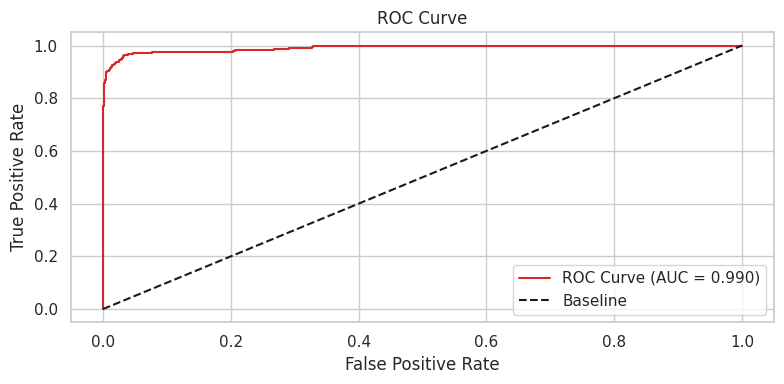

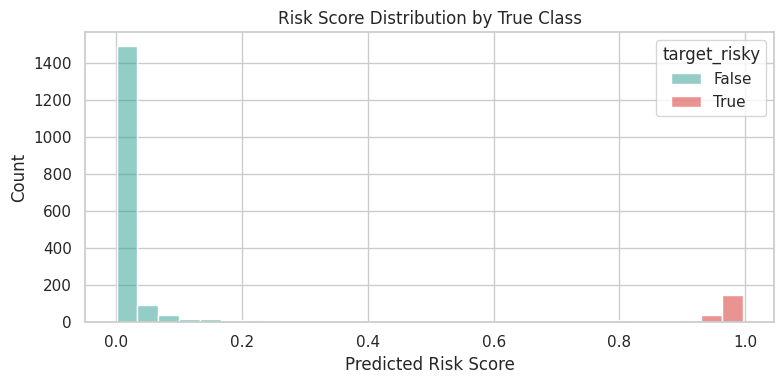

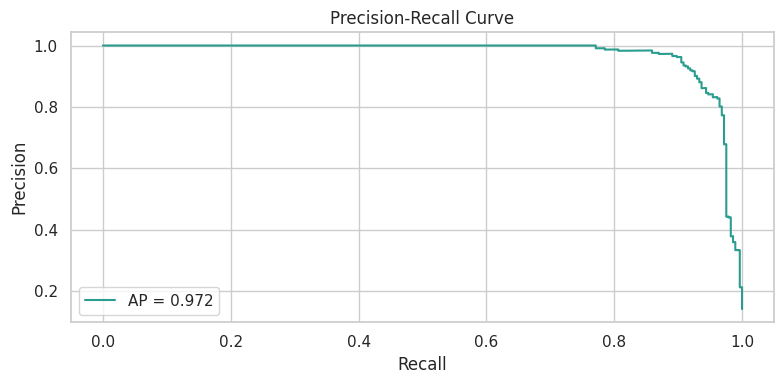

In [16]:
validation(test_df_v2, leak_cols_v2, model_v2, is_save_results=False)

In the updated model, we still observe a high AUC of 0.9962 on the test set, which is comparable to the previous result, despite using fewer features. This suggests that the model retains strong predictive power, even after removing potentially leaky or overly correlated features.

In [17]:
print("\nLeaderboard:")
leaderboard = model_v2.leaderboard(silent=True)
display(leaderboard)


Leaderboard:


,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.97375,accuracy,0.066067,9.668468,0.000650,0.082898,2,True,14
1,LightGBM,0.96875,accuracy,0.003146,0.628766,0.003146,0.628766,1,True,4
2,CatBoost,0.96875,accuracy,0.004099,2.534107,0.004099,2.534107,1,True,7
3,XGBoost,0.96625,accuracy,0.006657,0.547064,0.006657,0.547064,1,True,11
4,LightGBMLarge,0.96500,accuracy,0.006453,1.788142,0.006453,1.788142,1,True,13
5,NeuralNetTorch,0.96250,accuracy,0.013668,15.573431,0.013668,15.573431,1,True,12
6,LightGBMXT,0.96125,accuracy,0.002825,0.628518,0.002825,0.628518,1,True,3
7,NeuralNetFastAI,0.95875,accuracy,0.016705,5.853217,0.016705,5.853217,1,True,10
8,RandomForestEntr,0.95875,accuracy,0.134310,0.988758,0.134310,0.988758,1,True,6
9,RandomForestGini,0.95500,accuracy,0.151060,1.095533,0.151060,1.095533,1,True,5


In the results above, we observe that the WeightedEnsemble_L2 model continues to outperform individual models, achieving 97% accuracy on the validation set and 99% accuracy on the test set. This further confirms the ensemble’s ability to combine multiple model strengths for optimal predictive performance.

Note: WeightedEnsemble_L2 model is combination of stack_level 1 models i.e, LightGBM, CatBoost etc.

/home/anish/continues-learning/customer-risk-prediction/src/data_vis_utils.py:206: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='score_val', y='model', palette=color_map)


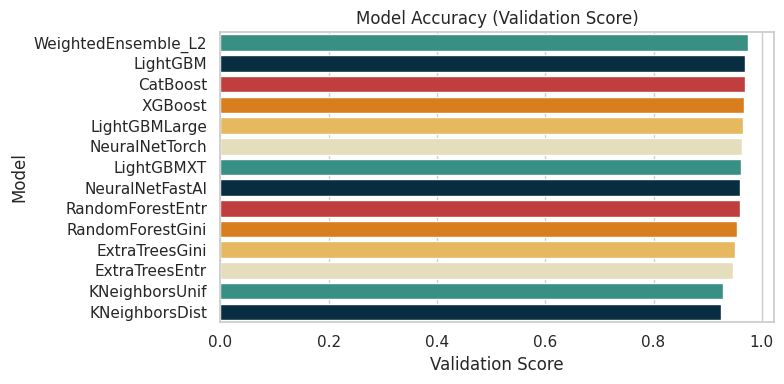

In [18]:
plot_model_leaderboard(leaderboard)

### Weighted Ensemble L2 Models

Let’s now examine the composition of the WeightedEnsemble L2 model to understand which base models contributed to its performance and how they were weighted in the final ensemble.

In [19]:
info = model_v2.info()
ensemble_weights = info['model_info']['WeightedEnsemble_L2']['children_info']['S1F1']['model_weights']
print(ensemble_weights)


{'KNeighborsUnif': 0.058823529411764705, 'LightGBM': 0.47058823529411764, 'CatBoost': 0.058823529411764705, 'NeuralNetFastAI': 0.17647058823529413, 'XGBoost': 0.23529411764705882}


This indicates that CatBoost had the most influence in the ensemble’s predictions, followed by the Neural Network model.

### Features Importance

These features in provided data are not utilized by the predictor and will be ignored: ['customer_account', 'total_balance', 'unpaid_ratio', 'aged_debt_count', 'aged_debt_amount']
Computing feature importance via permutation shuffling for 17 features using 5000 rows with 5 shuffle sets...
	16.35s	= Expected runtime (3.27s per shuffle set)
	9.58s	= Actual runtime (Completed 5 of 5 shuffle sets)
/home/anish/continues-learning/customer-risk-prediction/src/data_vis_utils.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='importance', y='index', palette=palette)
/home/anish/continues-learning/customer-risk-prediction/src/data_vis_utils.py:146: UserWarning: 
The palette list has fewer values (6) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='importance', y='index', palette=p

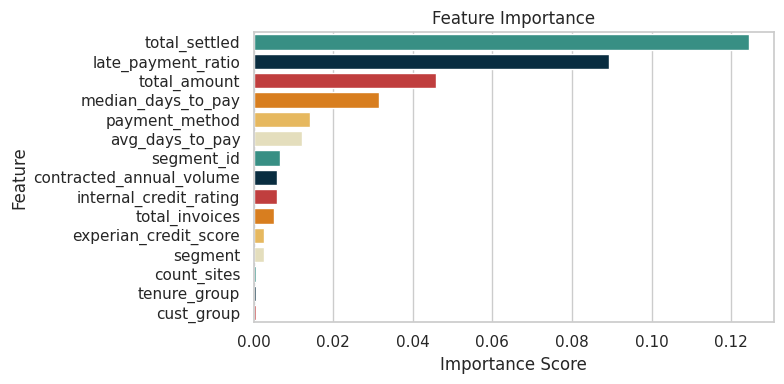

In [20]:
feature_raw = model_v2.feature_importance(train_df).reset_index().sort_values("importance", ascending=True)
plot_feature_importance(feature_raw, top_n=15)


The chart above highlights the feature importance scores from the final model. The top contributors are late_payment_ratio, total_settled, and median_days_to_pay, indicating that actual payment behavior has the strongest influence on predicting risk.

Interestingly, internal_credit_rating shows moderate importance, while experian_credit_score ranks lower. This suggests that the internal credit rating system is somewhat aligned with real payment risk, though it is not the primary driver of the model’s predictions. Overall, the model appears to rely more on observed transactional behavior than on credit scores alone.

## Final Risk Score generation for all the data

Let's now create a final risk score for all the customers. We will use model v2 for our inference. 

In [21]:

df = pd.read_csv("dataset/gold/gold_customer_features.csv")
 
df['target_risky'] = df['unpaid_ratio'] > risk_threshold  

final_set = df.drop(columns=leak_cols_v2)
test_df = df.copy() 

probas = model_v2.predict_proba(final_set)

# Add risk probabilities to test set
test_df['risk_probability'] = probas[probas.columns[-1]]

risk_score_filename="clean_risk_scores.csv"
test_df[['customer_account', 'risk_probability']].to_csv(f"models/{risk_score_filename}", index=False)



Our model v2 predicts customer payment risk using settlement amounts, historical payment delays, and credit behaviour not just if they already had aged debt.


# Risk Customer based on the model v2



Let's reload the final csv and then look at the customer based on the risk prediction

In [22]:
# Load risk scores + customer features
df = pd.read_csv("dataset/gold/gold_customer_features.csv")
risk_scores = pd.read_csv("models/clean_risk_scores.csv")

df = df.merge(risk_scores, on="customer_account", how="left")
df['customer_account'] = df['customer_account'].astype(str)

### Top 20 Customers by Risk-Weighted Exposure

/home/anish/continues-learning/customer-risk-prediction/src/data_vis_utils.py:268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=x, y=y, palette=palette)


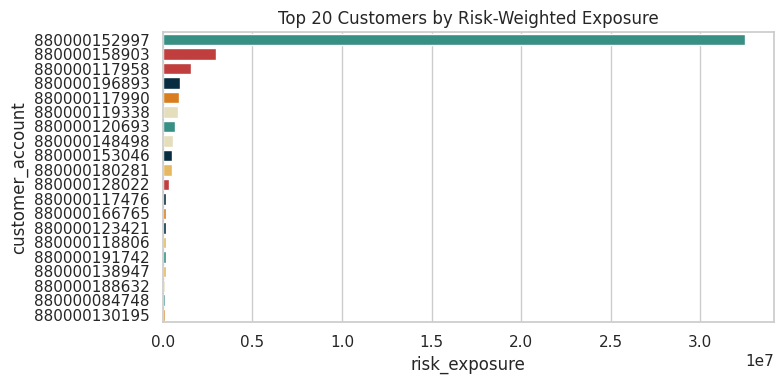

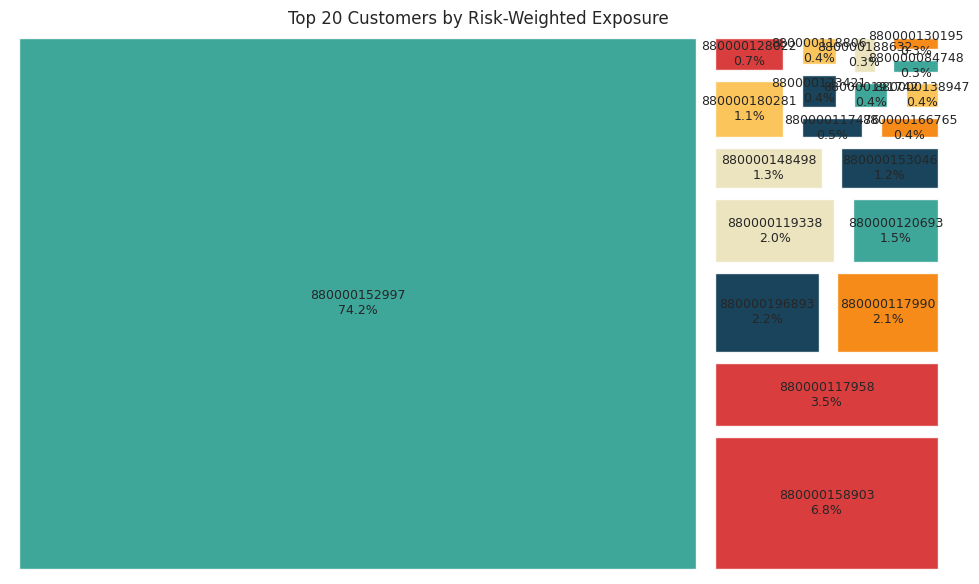

In [23]:

df['risk_exposure'] = df['risk_probability'] * df['total_balance']
top_exposure = df.sort_values('risk_exposure', ascending=False).head(20)
color_map = get_category_color_map(top_exposure, 'customer_account')

plot_bar_chart(
    df=top_exposure,
    x='risk_exposure',
    y='customer_account',
    title="Top 20 Customers by Risk-Weighted Exposure",
    orientation='h',
    palette = color_map
)


plot_treemap(
    top_exposure,
    'customer_account',
    value_col='risk_exposure',
    title="Top 20 Customers by Risk-Weighted Exposure",
    category_palette=color_map
)



In [24]:
top_exposure[top_exposure['customer_account'] == '880000152997']

,customer_account,total_invoices,total_amount,total_settled,total_balance,avg_days_to_pay,median_days_to_pay,late_payment_ratio,unpaid_ratio,aged_debt_count,...,cust_group,sme_mbs,payment_method,sales_route,segment,count_sites,tenure_group,contracted_annual_volume,risk_probability,risk_exposure
8389,880000152997,1042,1.371057e+08,1.001623e+08,36943370.88,83.323877,93.0,0.259117,0.59405,451,...,LTD,MBS,NONDD,Indirect,Flexi,8578,1-3 years,482794520,0.879234,3.248186e+07


In the output above, we identify the top 20 high-risk customers based on the model’s predictions. The customer with ID 88000001252997 ranks highest in predicted risk, followed by 880000158903 and others.

### Risk vs Internal Credit Rating

/home/anish/continues-learning/customer-risk-prediction/src/data_vis_utils.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=group_col, y=value_col, palette=category_palette)


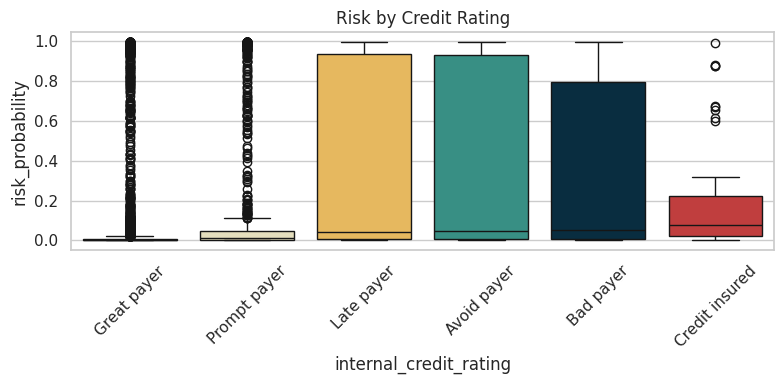

In [25]:
credit_order = [
    'Great payer', 'Prompt payer', 'Late payer',
    'Avoid payer', 'Bad payer', 'Credit insured'
]

color_map = get_category_color_map(pd.DataFrame({'internal_credit_rating': credit_order}), 'internal_credit_rating')

plot_box_by_group(df, 'internal_credit_rating', 'risk_probability', title="Risk by Credit Rating", category_palette=color_map)


In the chart above, we observe that the model’s predicted risk probabilities generally align with the internal credit rating tiers. Customers labeled as Great Payer and Prompt Payer show low median risk, with most falling in the lower range - suggesting consistency between internal assessments and model outputs.

However, Late Payers and Avoid Payers exhibit much wider and higher risk distributions, even exceeding that of Bad Payers, indicating that these groups may be underrepresented in the internal scoring system. Interestingly, Credit Insured customers tend to show low predicted risk, though a few outliers indicate elevated risk levels.

**A key takeaway is that some customers rated internally as “Great” or “Prompt” payers still have high model - predicted risk, highlighting potential blind spots in the internal credit system. This reinforces the value of using behavioral data-driven models to augment traditional credit assessment methods.**